In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

sns.set(style="whitegrid", context="notebook")


In [ ]:
df = pd.read_csv("D:\\DS Assignment\\PCA\\PCA\\wine.csv")

df.head(), df.shape, df.dtypes


(   Type  Alcohol  Malic   Ash  Alcalinity  Magnesium  Phenols  Flavanoids  \
 0     1    14.23   1.71  2.43        15.6        127     2.80        3.06   
 1     1    13.20   1.78  2.14        11.2        100     2.65        2.76   
 2     1    13.16   2.36  2.67        18.6        101     2.80        3.24   
 3     1    14.37   1.95  2.50        16.8        113     3.85        3.49   
 4     1    13.24   2.59  2.87        21.0        118     2.80        2.69   
 
    Nonflavanoids  Proanthocyanins  Color   Hue  Dilution  Proline  
 0           0.28             2.29   5.64  1.04      3.92     1065  
 1           0.26             1.28   4.38  1.05      3.40     1050  
 2           0.30             2.81   5.68  1.03      3.17     1185  
 3           0.24             2.18   7.80  0.86      3.45     1480  
 4           0.39             1.82   4.32  1.04      2.93      735  ,
 (178, 14),
 Type                 int64
 Alcohol            float64
 Malic              float64
 Ash               

In [3]:
print(df.info())
print("\nMissing values per column:\n", df.isna().sum())
print("\nDescriptive stats:\n", df.describe().T)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Type             178 non-null    int64  
 1   Alcohol          178 non-null    float64
 2   Malic            178 non-null    float64
 3   Ash              178 non-null    float64
 4   Alcalinity       178 non-null    float64
 5   Magnesium        178 non-null    int64  
 6   Phenols          178 non-null    float64
 7   Flavanoids       178 non-null    float64
 8   Nonflavanoids    178 non-null    float64
 9   Proanthocyanins  178 non-null    float64
 10  Color            178 non-null    float64
 11  Hue              178 non-null    float64
 12  Dilution         178 non-null    float64
 13  Proline          178 non-null    int64  
dtypes: float64(11), int64(3)
memory usage: 19.6 KB
None

Missing values per column:
 Type               0
Alcohol            0
Malic              0
Ash       

In [ ]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols


['Type',
 'Alcohol',
 'Malic',
 'Ash',
 'Alcalinity',
 'Magnesium',
 'Phenols',
 'Flavanoids',
 'Nonflavanoids',
 'Proanthocyanins',
 'Color',
 'Hue',
 'Dilution',
 'Proline']

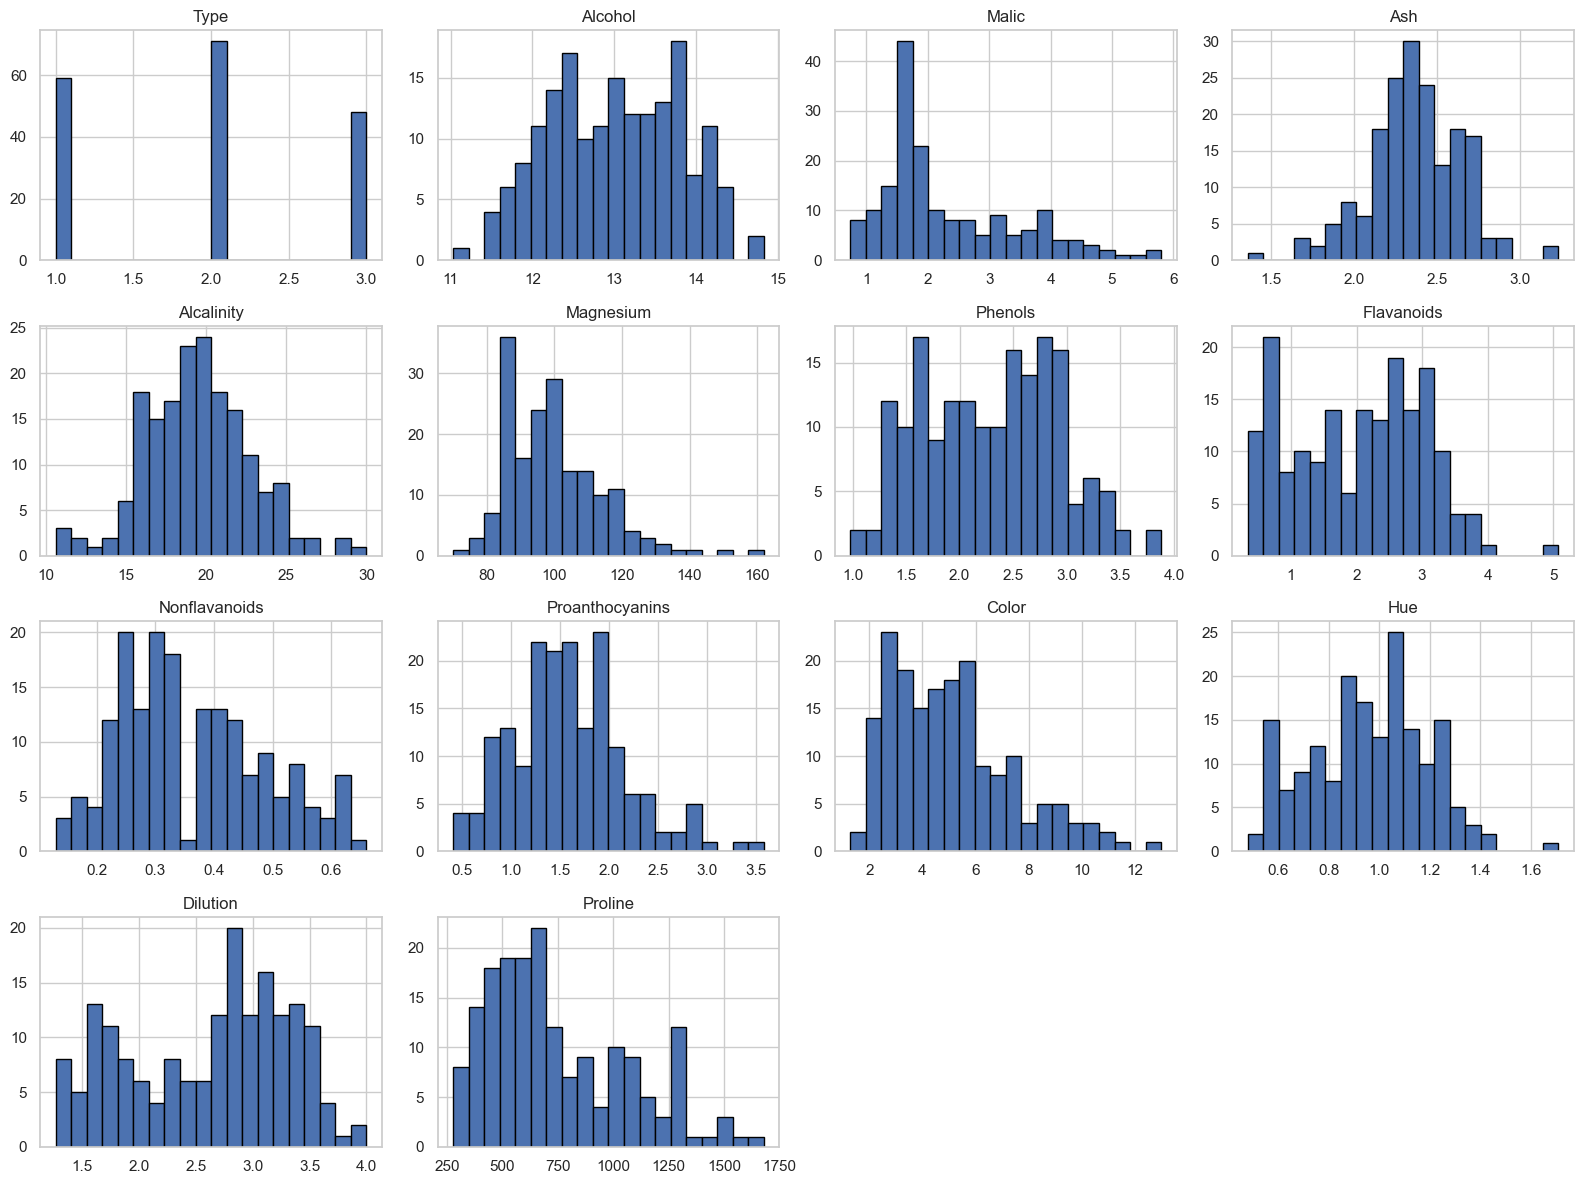

In [5]:
df[numeric_cols].hist(figsize=(16, 12), bins=20, edgecolor='black')
plt.tight_layout()
plt.show()


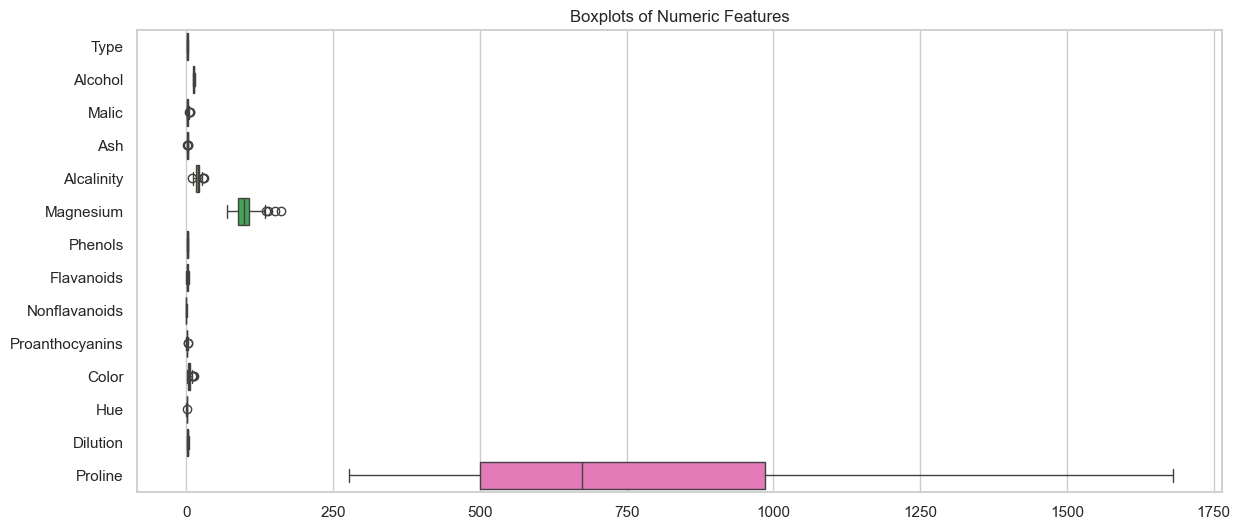

In [6]:
plt.figure(figsize=(14, 6))
sns.boxplot(data=df[numeric_cols], orient='h')
plt.title("Boxplots of Numeric Features")
plt.show()


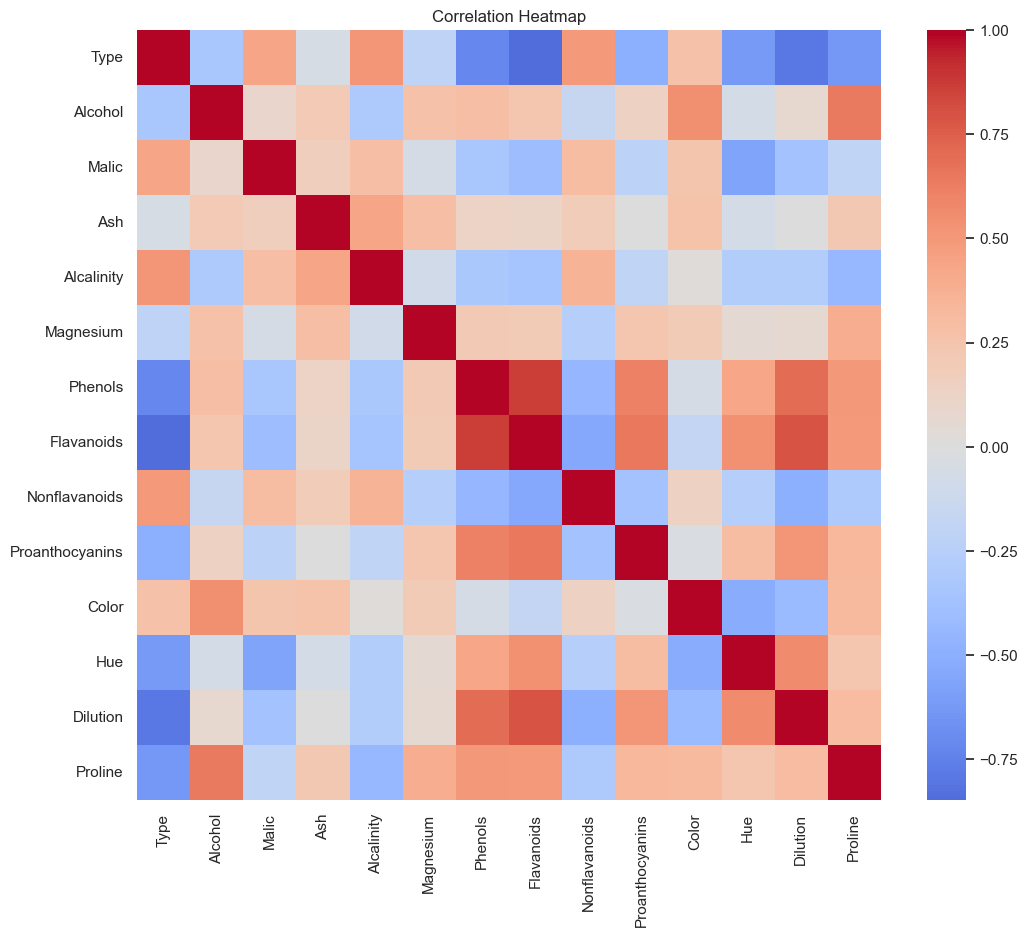

In [7]:
plt.figure(figsize=(12, 10))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=False, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()


In [8]:
label_col = "Type" if "Type" in df.columns else None

if label_col is not None:
    y_label = df[label_col].copy()
    X = df.drop(columns=[label_col]).copy()
else:
    y_label = None
    X = df.copy()

X.head(), (y_label.head() if y_label is not None else "No label column")


(   Alcohol  Malic   Ash  Alcalinity  Magnesium  Phenols  Flavanoids  \
 0    14.23   1.71  2.43        15.6        127     2.80        3.06   
 1    13.20   1.78  2.14        11.2        100     2.65        2.76   
 2    13.16   2.36  2.67        18.6        101     2.80        3.24   
 3    14.37   1.95  2.50        16.8        113     3.85        3.49   
 4    13.24   2.59  2.87        21.0        118     2.80        2.69   
 
    Nonflavanoids  Proanthocyanins  Color   Hue  Dilution  Proline  
 0           0.28             2.29   5.64  1.04      3.92     1065  
 1           0.26             1.28   4.38  1.05      3.40     1050  
 2           0.30             2.81   5.68  1.03      3.17     1185  
 3           0.24             2.18   7.80  0.86      3.45     1480  
 4           0.39             1.82   4.32  1.04      2.93      735  ,
 0    1
 1    1
 2    1
 3    1
 4    1
 Name: Type, dtype: int64)

In [9]:
scaler = StandardScaler()
X_std = scaler.fit_transform(X)

X_std[:3], X.columns.tolist()


(array([[ 1.51861254, -0.5622498 ,  0.23205254, -1.16959318,  1.91390522,
          0.80899739,  1.03481896, -0.65956311,  1.22488398,  0.25171685,
          0.36217728,  1.84791957,  1.01300893],
        [ 0.24628963, -0.49941338, -0.82799632, -2.49084714,  0.01814502,
          0.56864766,  0.73362894, -0.82071924, -0.54472099, -0.29332133,
          0.40605066,  1.1134493 ,  0.96524152],
        [ 0.19687903,  0.02123125,  1.10933436, -0.2687382 ,  0.08835836,
          0.80899739,  1.21553297, -0.49840699,  2.13596773,  0.26901965,
          0.31830389,  0.78858745,  1.39514818]]),
 ['Alcohol',
  'Malic',
  'Ash',
  'Alcalinity',
  'Magnesium',
  'Phenols',
  'Flavanoids',
  'Nonflavanoids',
  'Proanthocyanins',
  'Color',
  'Hue',
  'Dilution',
  'Proline'])

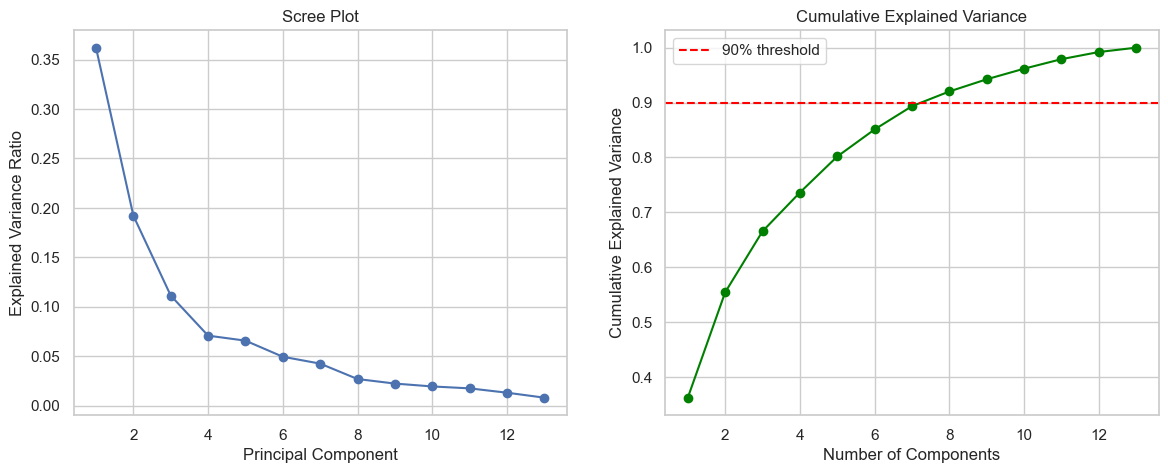

(array([0.36198848, 0.1920749 , 0.11123631, 0.0706903 , 0.06563294,
        0.04935823, 0.04238679, 0.02680749, 0.02222153, 0.01930019,
        0.01736836, 0.01298233, 0.00795215]),
 array([0.36198848, 0.55406338, 0.66529969, 0.73598999, 0.80162293,
        0.85098116, 0.89336795, 0.92017544, 0.94239698, 0.96169717,
        0.97906553, 0.99204785, 1.        ]))

In [10]:
pca_full = PCA()
pca_full.fit(X_std)

explained_var = pca_full.explained_variance_ratio_
cum_explained = np.cumsum(explained_var)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].plot(range(1, len(explained_var)+1), explained_var, marker='o')
ax[0].set_xlabel('Principal Component')
ax[0].set_ylabel('Explained Variance Ratio')
ax[0].set_title('Scree Plot')

ax[1].plot(range(1, len(cum_explained)+1), cum_explained, marker='o', color='green')
ax[1].axhline(0.90, color='red', linestyle='--', label='90% threshold')
ax[1].set_xlabel('Number of Components')
ax[1].set_ylabel('Cumulative Explained Variance')
ax[1].set_title('Cumulative Explained Variance')
ax[1].legend()
plt.show()

explained_var, cum_explained


In [11]:
target = 0.90
k_opt = int(np.argmax(cum_explained >= target) + 1)
k_opt


8

In [12]:
pca = PCA(n_components=k_opt)
X_pca = pca.fit_transform(X_std)

X_std.shape, X_pca.shape, X_pca[:3]


((178, 13),
 (178, 8),
 array([[ 3.31675081,  1.44346263, -0.16573904, -0.21563119,  0.69304284,
          0.22388013,  0.59642655, -0.06513909],
        [ 2.20946492, -0.33339289, -2.02645737, -0.29135832, -0.25765463,
          0.92712024,  0.05377561, -1.02441595],
        [ 2.51674015,  1.0311513 ,  0.98281867,  0.72490231, -0.25103312,
         -0.54927605,  0.42420545,  0.34421613]]))

In [13]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=X.columns,
    columns=[f"PC{i+1}" for i in range(k_opt)]
)
loadings.sort_values("PC1", ascending=False).head(10), loadings.head()


(                      PC1       PC2       PC3       PC4       PC5       PC6  \
 Flavanoids       0.422934 -0.003360  0.150682  0.152295 -0.109026 -0.018920   
 Phenols          0.394661  0.065040  0.146179  0.198068 -0.149318 -0.084122   
 Dilution         0.376167 -0.164496  0.166005  0.184121 -0.101161  0.265851   
 Proanthocyanins  0.313429  0.039302  0.149454  0.399057  0.136860 -0.533795   
 Hue              0.296715 -0.279235  0.085222 -0.427771 -0.173615  0.105983   
 Proline          0.286752  0.364903 -0.126746 -0.232071 -0.157869  0.119726   
 Alcohol          0.144329  0.483652 -0.207383 -0.017856 -0.265664  0.213539   
 Magnesium        0.141992  0.299634  0.130757 -0.351797  0.727049  0.038144   
 Ash             -0.002051  0.316069  0.626224 -0.214176 -0.143025  0.154475   
 Color           -0.088617  0.529996 -0.137306  0.065926 -0.076437 -0.418644   
 
                       PC7       PC8  
 Flavanoids      -0.060685 -0.187245  
 Phenols         -0.027925 -0.405934  
 

c:\Users\Sanskar\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Sanskar\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Sanskar\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Sanskar\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak o

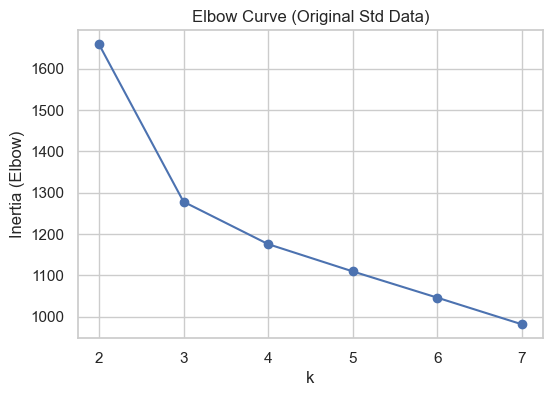

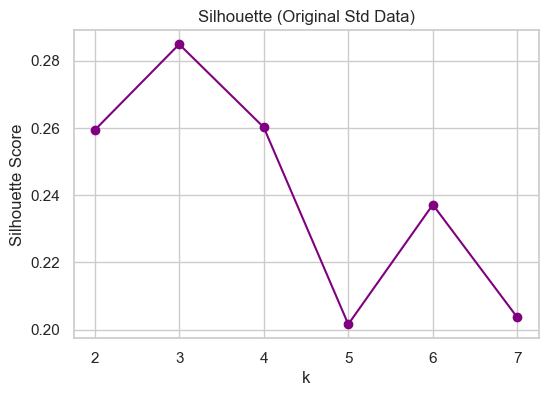

[(2, 1658.758852429095, np.float64(0.25931695553182543)),
 (3, 1277.9284888446423, np.float64(0.2848589191898986)),
 (4, 1175.4283331033473, np.float64(0.2601703522370452)),
 (5, 1109.5127392938243, np.float64(0.2016190829407409)),
 (6, 1046.0023332143637, np.float64(0.23716725754166543)),
 (7, 981.5952326111657, np.float64(0.2036275812271175))]

In [14]:
inertias = []
sil_scores = []
ks = range(2, 8)

for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels_k = km.fit_predict(X_std)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_std, labels_k))

fig, ax1 = plt.subplots(figsize=(6,4))
ax1.plot(ks, inertias, marker='o')
ax1.set_xlabel('k')
ax1.set_ylabel('Inertia (Elbow)')
ax1.set_title('Elbow Curve (Original Std Data)')
plt.show()

fig, ax2 = plt.subplots(figsize=(6,4))
ax2.plot(ks, sil_scores, marker='o', color='purple')
ax2.set_xlabel('k')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette (Original Std Data)')
plt.show()

list(zip(ks, inertias, sil_scores))


In [ ]:
k_best = 3 
kmeans_orig = KMeans(n_clusters=k_best, n_init=10, random_state=42)
labels_orig = kmeans_orig.fit_predict(X_std)

sil_orig = silhouette_score(X_std, labels_orig)
db_orig = davies_bouldin_score(X_std, labels_orig)
sil_orig, db_orig


c:\Users\Sanskar\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


(np.float64(0.2848589191898986), np.float64(1.389187977718165))

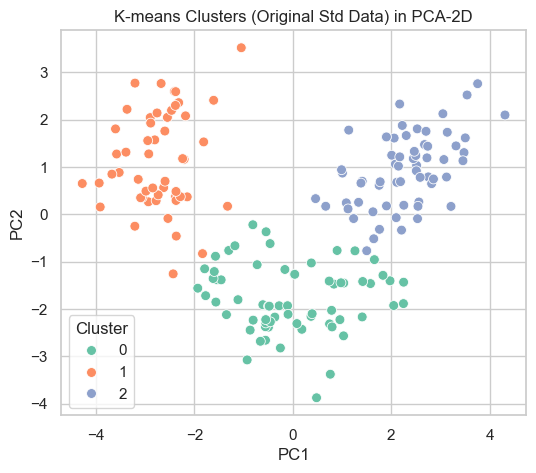

In [16]:
pca2 = PCA(n_components=2).fit(X_std)
X_2d = pca2.transform(X_std)

plt.figure(figsize=(6,5))
sns.scatterplot(x=X_2d[:,0], y=X_2d[:,1], hue=labels_orig, palette='Set2', s=50)
plt.title("K-means Clusters (Original Std Data) in PCA-2D")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="Cluster")
plt.show()


c:\Users\Sanskar\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Sanskar\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Sanskar\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Sanskar\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak o

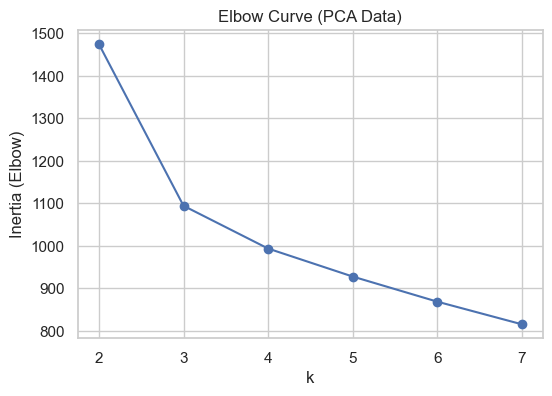

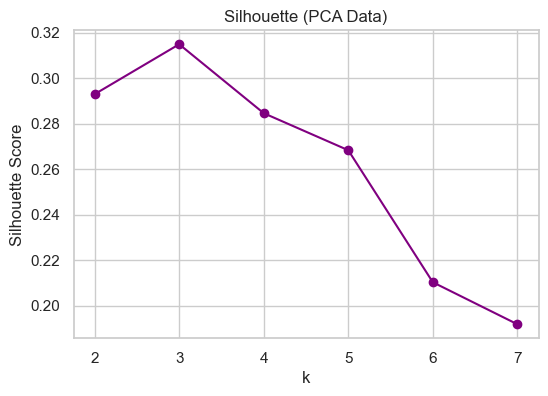

[(2, 1474.453548004335, np.float64(0.2930048322039009)),
 (3, 1094.3755715999969, np.float64(0.314969695470556)),
 (4, 993.7832402312611, np.float64(0.2846414058368013)),
 (5, 927.9434560829288, np.float64(0.2683445820350233)),
 (6, 868.8719044528572, np.float64(0.21026788466518143)),
 (7, 815.6385325769868, np.float64(0.1917880190234759))]

In [17]:
inertias_pca = []
sil_scores_pca = []

for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels_k = km.fit_predict(X_pca)
    inertias_pca.append(km.inertia_)
    sil_scores_pca.append(silhouette_score(X_pca, labels_k))

fig, ax1 = plt.subplots(figsize=(6,4))
ax1.plot(ks, inertias_pca, marker='o')
ax1.set_xlabel('k')
ax1.set_ylabel('Inertia (Elbow)')
ax1.set_title('Elbow Curve (PCA Data)')
plt.show()

fig, ax2 = plt.subplots(figsize=(6,4))
ax2.plot(ks, sil_scores_pca, marker='o', color='purple')
ax2.set_xlabel('k')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette (PCA Data)')
plt.show()

list(zip(ks, inertias_pca, sil_scores_pca))


In [18]:
kmeans_pca = KMeans(n_clusters=k_best, n_init=10, random_state=42)
labels_pca = kmeans_pca.fit_predict(X_pca)

sil_pca = silhouette_score(X_pca, labels_pca)
db_pca = davies_bouldin_score(X_pca, labels_pca)
sil_pca, db_pca


c:\Users\Sanskar\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


(np.float64(0.314969695470556), np.float64(1.2668818314972186))

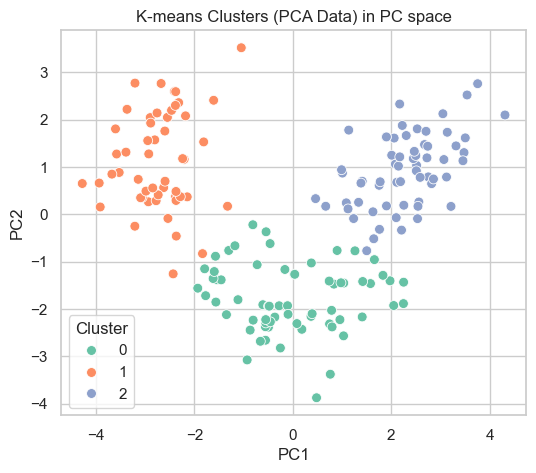

In [19]:
plt.figure(figsize=(6,5))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=labels_pca, palette='Set2', s=50)
plt.title("K-means Clusters (PCA Data) in PC space")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="Cluster")
plt.show()


In [20]:
if label_col is not None:
    comp_df = pd.DataFrame({
        "Type": y_label.values,
        "Cluster_Orig": labels_orig,
        "Cluster_PCA": labels_pca
    })
    print("Original vs Type:\n", pd.crosstab(comp_df["Type"], comp_df["Cluster_Orig"]))
    print("\nPCA vs Type:\n", pd.crosstab(comp_df["Type"], comp_df["Cluster_PCA"]))
else:
    print("No label column found; skipping label comparison.")


Original vs Type:
 Cluster_Orig   0   1   2
Type                    
1              0   0  59
2             65   3   3
3              0  48   0

PCA vs Type:
 Cluster_PCA   0   1   2
Type                   
1             0   0  59
2            65   3   3
3             0  48   0


In [21]:
results = pd.DataFrame({
    "Space": [f"Original (std)", f"PCA (k={k_opt})"],
    "k": [k_best, k_best],
    "Silhouette": [sil_orig, sil_pca],
    "DaviesBouldin": [db_orig, db_pca]
})
results


,Space,k,Silhouette,DaviesBouldin
0,Original (std),3,0.284859,1.389188
1,PCA (k=8),3,0.314970,1.266882
